<a href="https://colab.research.google.com/github/Jokooo1/Jokoosrtyo/blob/main/BISINDO_YOLOv11_COLAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BISINDO Sign Language Recognition — YOLOv11 (Google Colab)

**PENTING: Jalankan cell dari atas ke bawah SECARA URUT.**
Jangan loncat-loncat atau run cell training sebelum cell dataset selesai jalan.

**Sebelum mulai:**
1. Runtime → Change runtime type → pilih **T4 GPU** → Save
2. Upload file zip dataset kamu ke Colab (klik ikon folder 📁 di kiri → ikon upload)


## 1. Cek GPU aktif

In [ ]:
!nvidia-smi


Sun Jul 12 13:13:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Install Dependencies

In [ ]:
!pip install ultralytics -q


## 3. Cek File Zip yang Sudah Diupload


In [ ]:
!ls /content


 bisindo_dataset		    runs	  yolo11n.pt
'BISINDO Dataset.v3i.yolov11.zip'   sample_data   yolo26n.pt


## 4. Extract Dataset

⚠️ Ganti `ZIP_FILENAME` di bawah SESUAI PERSIS nama file yang muncul
di hasil `!ls /content` pada cell sebelumnya.


In [ ]:
import zipfile
import os

ZIP_FILENAME = "BISINDO Dataset.v3i.yolov11.zip"  # <-- ganti kalau nama file kamu beda
EXTRACT_DIR = "/content/bisindo_dataset"

with zipfile.ZipFile(f"/content/{ZIP_FILENAME}", "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("✅ Selesai extract. Isi folder:")
print(os.listdir(EXTRACT_DIR))


✅ Selesai extract. Isi folder:
['train', 'valid', 'data.yaml', 'test', 'README.dataset.txt', 'README.roboflow.txt']


## 5. WAJIB: Set & Verifikasi Path Dataset

Cell ini HARUS dijalankan dan HARUS menampilkan `True` sebelum
lanjut ke cell training. Kalau `False`, JANGAN lanjut — screenshot
hasilnya dan tanyakan dulu.


In [ ]:
DATA_YAML = "/content/bisindo_dataset/data.yaml"

print("Path yang dipakai:", DATA_YAML)
print("File ditemukan?   :", os.path.exists(DATA_YAML))

if os.path.exists(DATA_YAML):
    print("\n--- Isi data.yaml ---")
    with open(DATA_YAML) as f:
        print(f.read())
else:
    print("\n❌ File tidak ditemukan di path itu. Menampilkan struktur folder asli:")
    for root, dirs, files in os.walk(EXTRACT_DIR):
        print(root, "->", files[:5])


Path yang dipakai: /content/bisindo_dataset/data.yaml
File ditemukan?   : True

--- Isi data.yaml ---
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 26
names: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'z']

roboflow:
  workspace: bisindo
  project: bisindo-dataset
  version: 3
  license: CC BY 4.0
  url: https://universe.roboflow.com/bisindo/bisindo-dataset/dataset/3


## 6. Training Model YOLOv11

In [ ]:
from ultralytics import YOLO

# Guard: pastikan DATA_YAML valid sebelum training dimulai
assert os.path.exists(DATA_YAML), f"❌ STOP: {DATA_YAML} tidak ditemukan. Jalankan ulang cell Step 4-5 di atas."

MODEL_BASE = "yolo11n.pt"   # nano = ringan & cepat
EPOCHS = 100
IMG_SIZE = 640
BATCH_SIZE = 16
PROJECT_DIR = "models"
RUN_NAME = "bisindo_yolo11"

model = YOLO(MODEL_BASE)

results = model.train(
    data=DATA_YAML,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    project=PROJECT_DIR,
    name=RUN_NAME,
    patience=20,
    device=0,     # GPU Colab
    plots=True,
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/bisindo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, 

## 7. Evaluasi Model

In [ ]:
metrics = model.val()
print(metrics)


Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,587,222 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 446.6±158.1 MB/s, size: 7.1 KB)
val: Scanning /content/bisindo_dataset/valid/labels.cache... 1335 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1335/1335 509.0Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 99, len(boxes) = 1335. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 84/84 6.7it/s 12.5s
                   all       1335       1335      0.997      0.999      0.995      0.993
                     A         44         44      0.998          1      0.995      0.995
                     B        

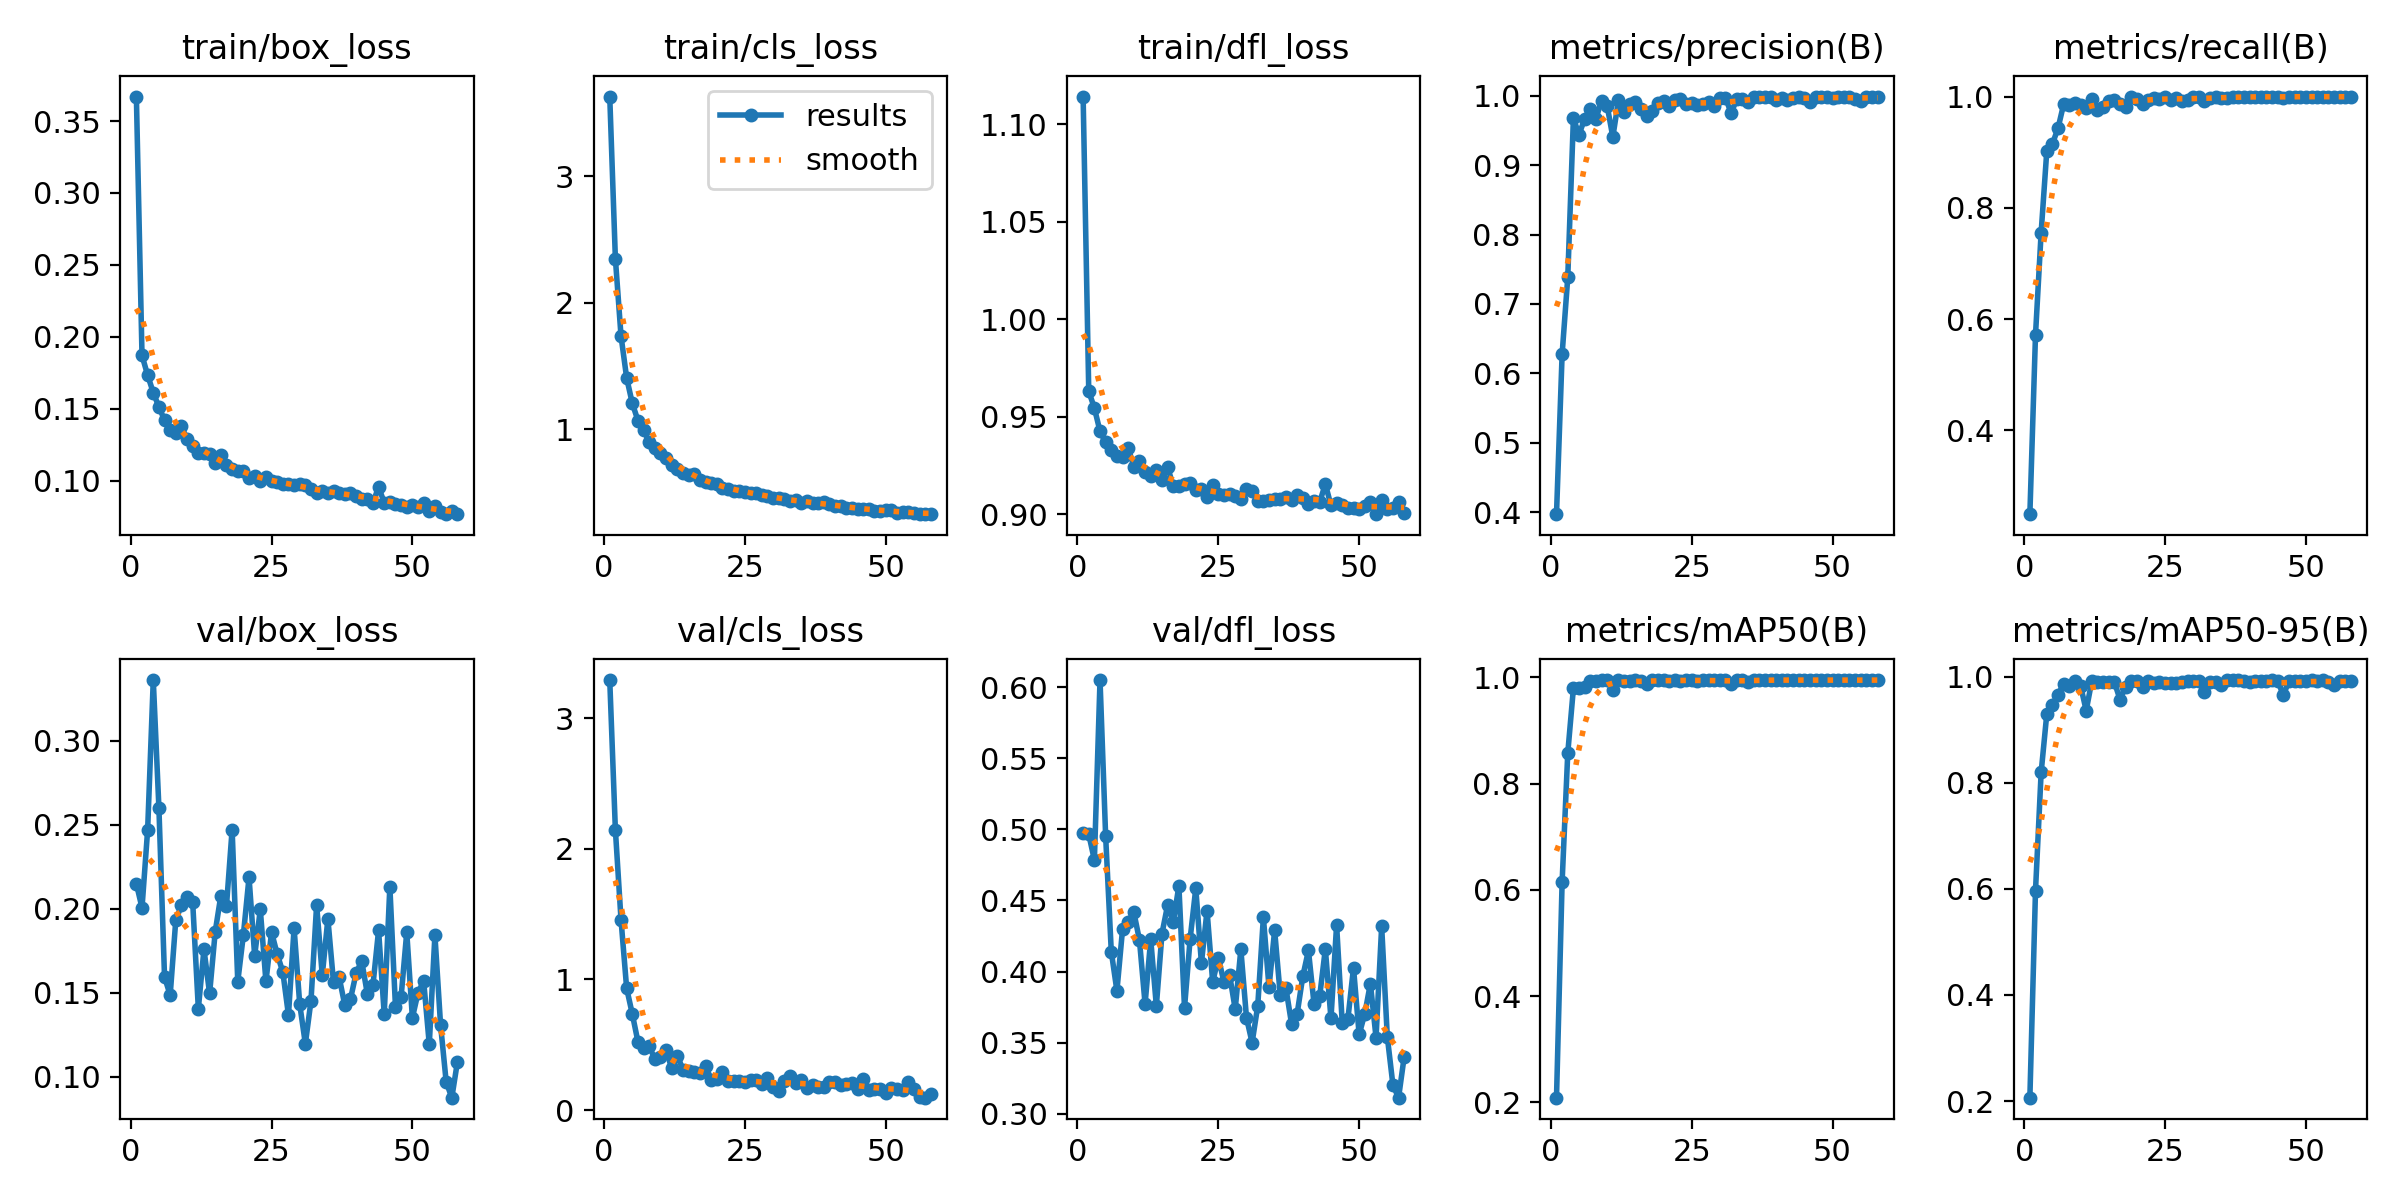

In [ ]:
from IPython.display import Image, display

display(Image(filename=f"runs/detect/{PROJECT_DIR}/{RUN_NAME}/results.png"))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

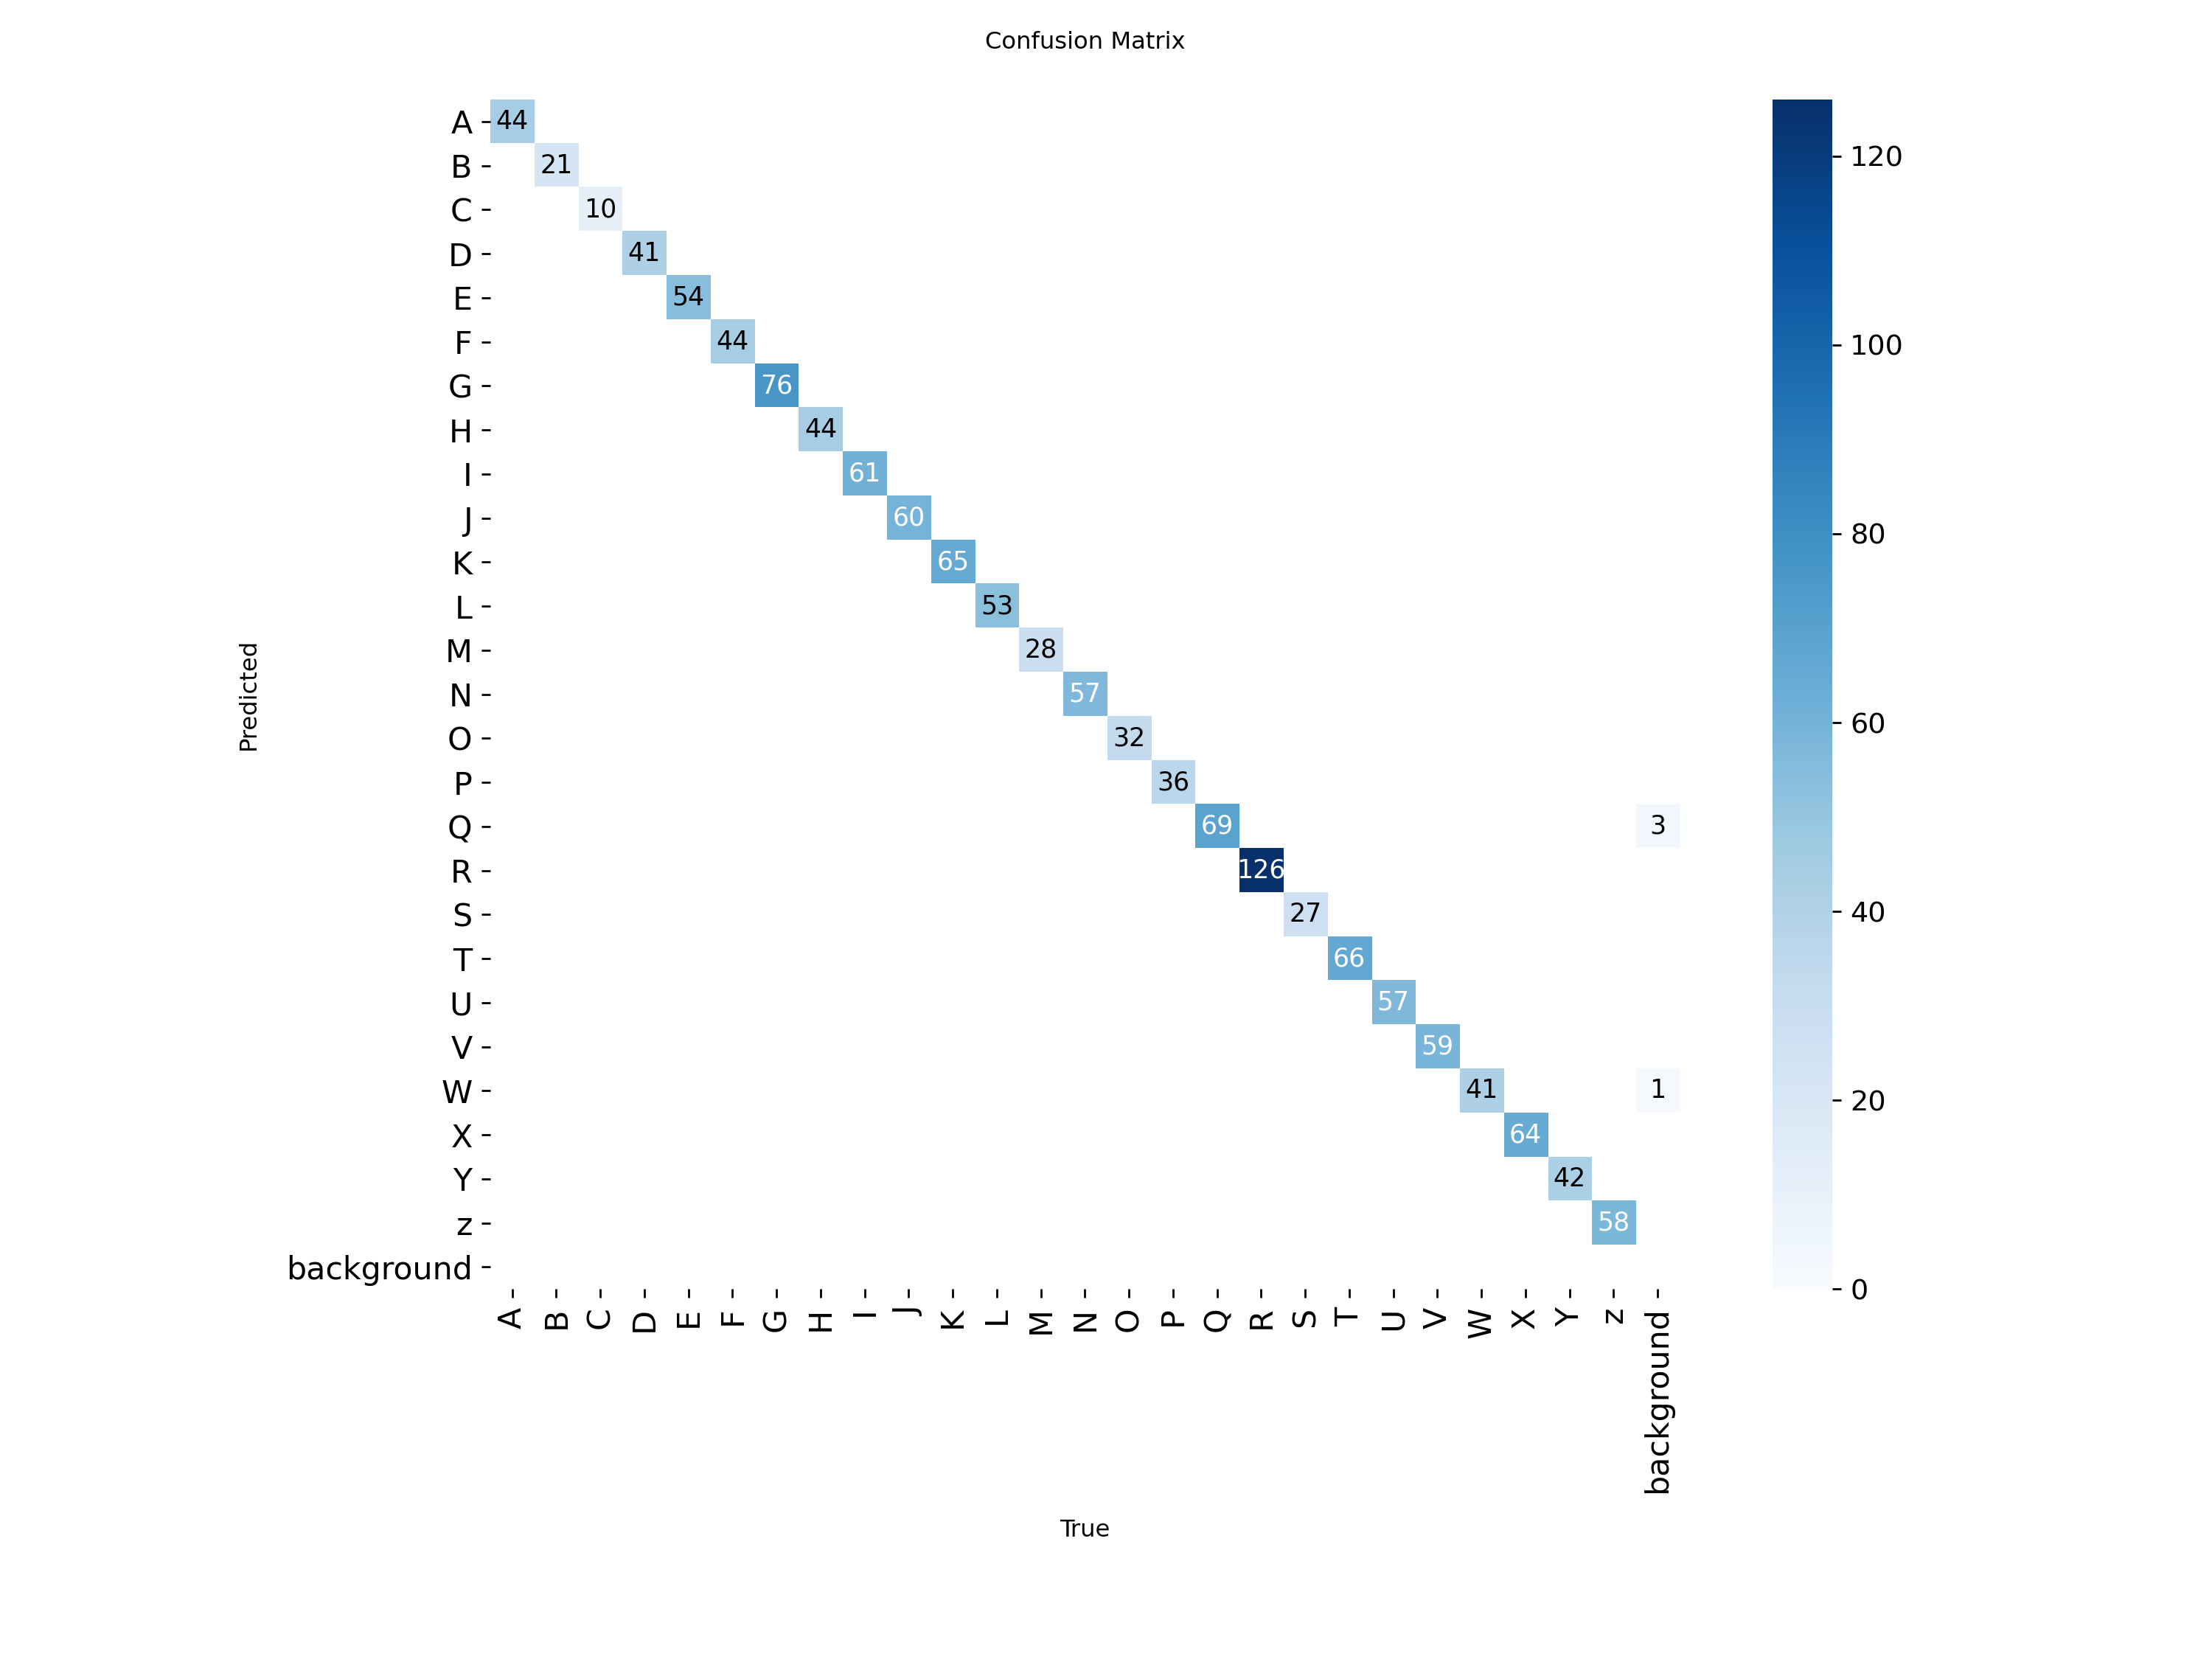

In [ ]:
display(Image(filename=f"runs/detect/{PROJECT_DIR}/{RUN_NAME}/confusion_matrix.png"))

## 8. Prediksi Contoh Gambar (opsional)

Upload gambar tangan dulu lewat panel kiri Colab (folder icon → upload),
lalu ganti nama file di bawah.



image 1/1 /content/contoh_tangan.jpg: 640x480 1 N, 10.3ms
Speed: 2.2ms preprocess, 10.3ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict-3
Huruf: N  (confidence: 0.66)


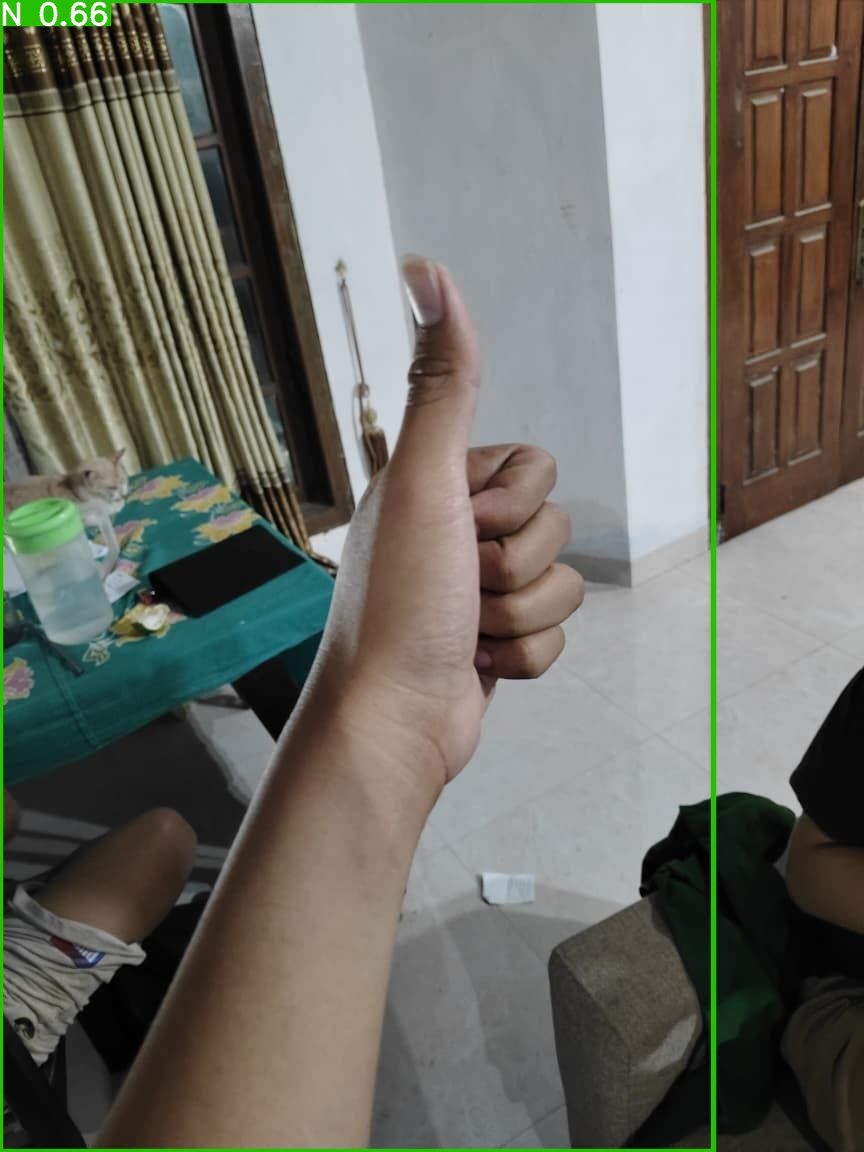

In [ ]:
from pathlib import Path # Tambahkan import ini

BEST_MODEL = f"runs/detect/{PROJECT_DIR}/{RUN_NAME}/weights/best.pt"
model_trained = YOLO(BEST_MODEL)

SOURCE_IMAGE = "contoh_tangan.jpg"  # ganti sesuai nama file yang diupload

results = model_trained.predict(source=SOURCE_IMAGE, conf=0.5, save=True)

for r in results:
    for box in r.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        print(f"Huruf: {model_trained.names[cls_id]}  (confidence: {conf:.2f})")

display(Image(filename=str(Path(results[0].save_dir) / SOURCE_IMAGE)))

## 9. Download Hasil Model (best.pt) ke Laptop

Ini langkah PENTING — supaya model hasil training bisa dipakai untuk
testing webcam real-time di VSCode/laptop kamu (Colab gak bisa akses webcam).


In [ ]:
from google.colab import files

files.download(f"runs/detect/{PROJECT_DIR}/{RUN_NAME}/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. (Opsional) Simpan Juga ke Google Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copytree(
    f"runs/detect/{PROJECT_DIR}/{RUN_NAME}",
    "/content/drive/MyDrive/bisindo_yolo11_hasil_training",
    dirs_exist_ok=True
)
print("✅ Tersimpan ke Google Drive: MyDrive/bisindo_yolo11_hasil_training")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Tersimpan ke Google Drive: MyDrive/bisindo_yolo11_hasil_training


---

## Langkah Selanjutnya (di laptop, VSCode)

1. File `best.pt` yang barusan didownload → pindahkan ke:
   `bisindo-yolo/models/bisindo_yolo11/weights/best.pt`
2. Jalankan testing webcam **lokal** (Colab gak bisa akses kamera):
   ```bash
   python scripts/detect_webcam.py
   ```
